# **User Analytics in the Telecommunication Industry - Overview**

### **TellCo Customer Analytics Project**

**Organization:** Nexthikes IT Solutions

**Project Objective:**  
Analyze customer behavior, engagement, network experience, and satisfaction using the TellCo telecommunication xDR dataset.

**Analysis Areas:**
1. User Overview Analysis
2. User Engagement Analysis
3. Experience Analytics
4. Satisfaction Analysis

## 1. **User Overview Analysis**

### 1.1 **Dataset Understanding and Preparation**

The first step of the analysis is to understand the telecommunication xDR dataset, its structure, variables, data types, missing values, duplicate records, and potential outliers.

The dataset will be examined and prepared before performing User Overview Analysis.

In [2]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Required libraries imported successfully.")

Required libraries imported successfully.


### 1.1.1 **Load the Dataset**

The telecom XDR dataset is loaded from the raw data folder for further analysis. The dataset will be used to understand customer usage patterns, network performance, and service-related behavior.

In [ ]:
# Load the telecom XDR dataset

file_path = "../data/raw/telcom_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")


Dataset loaded successfully.


### 1.1.2 **Basic Dataset Understanding**

The dataset is examined to understand its overall structure and dimensions. The first few records, number of rows and columns, and information about the variables are reviewed to understand the nature of the telecom XDR data before performing data quality assessment and further preparation.

In [ ]:
# Check the number of rows and columns

df.shape

(150001, 55)

In [ ]:
# Display the first five records

df.head()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),HTTP DL (Bytes),HTTP UL (Bytes),Activity Duration DL (ms),Activity Duration UL (ms),Dur. (ms).1,Handset Manufacturer,Handset Type,Nb of sec with 125000B < Vol DL,Nb of sec with 1250B < Vol UL < 6250B,Nb of sec with 31250B < Vol DL < 125000B,Nb of sec with 37500B < Vol UL,Nb of sec with 6250B < Vol DL < 31250B,Nb of sec with 6250B < Vol UL < 37500B,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,1.311450e+19,4/4/19 12:01,770.0,4/25/19 14:35,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9.16457E+15,42.0,5.0,23.0,44.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,37624.0,38787.0,1.823653e+09,Samsung,Samsung Galaxy A5 Sm-A520F,NaN,NaN,NaN,NaN,NaN,NaN,213.0,214.0,1545765.0,24420.0,1634479.0,1271433.0,3563542.0,137762.0,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,1.311450e+19,4/9/19 13:04,235.0,4/25/19 8:15,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,65.0,5.0,16.0,26.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,168.0,3560.0,1.365104e+09,Samsung,Samsung Galaxy J5 (Sm-J530),NaN,NaN,NaN,NaN,NaN,NaN,971.0,1022.0,1926113.0,7165.0,3493924.0,920172.0,629046.0,308339.0,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,1.311450e+19,4/9/19 17:42,1.0,4/25/19 11:58,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,NaN,NaN,6.0,9.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,1.361763e+09,Samsung,Samsung Galaxy A8 (2018),NaN,NaN,NaN,NaN,NaN,NaN,751.0,695.0,1684053.0,42224.0,8535055.0,1694064.0,2690151.0,672973.0,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,1.311450e+19,4/10/19 0:31,486.0,4/25/19 7:36,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,NaN,NaN,44.0,44.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,3330.0,37882.0,1.321510e+09,undefined,undefined,NaN,NaN,NaN,NaN,NaN,NaN,17.0,207.0,644121.0,13372.0,9023734.0,2788027.0,1439754.0,631229.0,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,1.311450e+19,4/12/19 20:10,565.0,4/25/19 10:40,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,NaN,NaN,6.0,9.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,1.089009e+09,Samsung,Samsung Sm-G390F,NaN,NaN,NaN,NaN,NaN,NaN,607.0,604.0,862600.0,50188.0,6248284.0,1500559.0,1936496.0,173853.0,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [ ]:
# Display the last five records

df.tail()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),HTTP DL (Bytes),HTTP UL (Bytes),Activity Duration DL (ms),Activity Duration UL (ms),Dur. (ms).1,Handset Manufacturer,Handset Type,Nb of sec with 125000B < Vol DL,Nb of sec with 1250B < Vol UL < 6250B,Nb of sec with 31250B < Vol DL < 125000B,Nb of sec with 37500B < Vol UL,Nb of sec with 6250B < Vol DL < 31250B,Nb of sec with 6250B < Vol UL < 37500B,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
149996,7.277830e+18,4/29/19 7:28,451.0,4/30/19 6:02,214.0,81230.0,2.082022e+14,3.365069e+10,3.548311e+13,D20434A,32.0,0.0,52.0,65.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,42376.0,41915.0,81230763.0,Apple,Apple iPhone 8 Plus (A1897),NaN,NaN,NaN,NaN,NaN,NaN,223.0,229.0,3464974.000,52091.00000,9967603.000,2817311.000,57639.000,633237.0000,16191667.0,11763428.00,17883703.00,19678161.00,526609673.0,9.197207e+06,3264510.0,1.348742e+07,57628851.0,574175259.0
149997,7.349880e+18,4/29/19 7:28,483.0,4/30/19 10:41,187.0,97970.0,2.082019e+14,3.366345e+10,3.566051e+13,D10223C,27.0,2.0,23.0,54.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,17264.0,16759.0,97970704.0,Apple,Apple iPhone Se (A1723),NaN,NaN,NaN,NaN,NaN,NaN,105.0,102.0,2344568.000,7613.00000,2229420.000,2185941.000,1954414.000,167304.0000,13877234.0,8288284.00,19350146.00,21293148.00,626893062.0,4.735033e+06,712180387.0,2.457758e+06,39135081.0,666648844.0
149998,1.311450e+19,4/29/19 7:28,283.0,4/30/19 10:46,810.0,98249.0,2.082017e+14,3.362189e+10,3.572121e+13,T51102A,43.0,6.0,43.0,47.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,25003.0,28640.0,98249527.0,Apple,Apple iPhone Xs (A2097),NaN,NaN,NaN,NaN,NaN,NaN,104.0,108.0,1245845.000,14394.00000,3850890.000,2734579.000,1525734.000,532543.0000,22660510.0,1855903.00,9963942.00,5065760.00,553539484.0,1.339432e+07,121100856.0,1.131473e+07,34912224.0,592786405.0
149999,1.311450e+19,4/29/19 7:28,696.0,4/30/19 10:40,327.0,97910.0,2.082021e+14,3.361962e+10,8.618620e+13,L88342B,37.0,5.0,34.0,37.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,13405.0,34088.0,97910631.0,Huawei,Huawei Fig-Lx1,NaN,NaN,NaN,NaN,NaN,NaN,43.0,82.0,801547.000,21562.00000,4189773.000,3567494.000,2228270.000,622644.0000,8817106.0,8305402.00,3322253.00,13172589.00,352536971.0,2.529475e+06,814713113.0,1.406930e+06,29626096.0,371895920.0
150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1795321.774,32928.43438,5750752.619,2056541.926,1791728.868,467373.4419,11634072.5,11009410.13,11626851.72,11001754.82,422044702.6,8.288398e+06,421100544.2,8.264799e+06,NaN,NaN


In [ ]:
# Display dataset information including data types and non-null counts

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Bearer Id                                 149010 non-null  float64
 1   Start                                     150000 non-null  str    
 2   Start ms                                  150000 non-null  float64
 3   End                                       150000 non-null  str    
 4   End ms                                    150000 non-null  float64
 5   Dur. (ms)                                 150000 non-null  float64
 6   IMSI                                      149431 non-null  float64
 7   MSISDN/Number                             148935 non-null  float64
 8   IMEI                                      149429 non-null  float64
 9   Last Location Name                        148848 non-null  str    
 10  Avg RTT DL (ms)                

In [ ]:
# Display the data type of each column

column_dtypes = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values
})

column_dtypes

,Column,Data Type
0,Bearer Id,float64
1,Start,str
2,Start ms,float64
3,End,str
4,End ms,float64
5,Dur. (ms),float64
6,IMSI,float64
7,MSISDN/Number,float64
8,IMEI,float64
9,Last Location Name,str


### 1.1.3 **Missing Values Check**

Missing values are checked for all variables to identify incomplete or unavailable data in the telecom XDR dataset. This step is important before performing further analysis and data cleaning.

In [ ]:
# Check missing values in each column

df.isnull().sum()

Bearer Id                                      991
Start                                            1
Start ms                                         1
End                                              1
End ms                                           1
Dur. (ms)                                        1
IMSI                                           570
MSISDN/Number                                 1066
IMEI                                           572
Last Location Name                            1153
Avg RTT DL (ms)                              27829
Avg RTT UL (ms)                              27812
Avg Bearer TP DL (kbps)                          1
Avg Bearer TP UL (kbps)                          1
TCP DL Retrans. Vol (Bytes)                  88146
TCP UL Retrans. Vol (Bytes)                  96649
DL TP < 50 Kbps (%)                            754
50 Kbps < DL TP < 250 Kbps (%)                 754
250 Kbps < DL TP < 1 Mbps (%)                  754
DL TP > 1 Mbps (%)             

In [ ]:
# Create a summary of columns containing missing values

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[missing_summary['Missing Values'] > 0]
missing_summary = missing_summary.sort_values(
    by='Missing Percentage',
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
Nb of sec with 37500B < Vol UL,130254,86.835421
Nb of sec with 6250B < Vol UL < 37500B,111843,74.561503
Nb of sec with 125000B < Vol DL,97538,65.024900
TCP UL Retrans. Vol (Bytes),96649,64.432237
Nb of sec with 31250B < Vol DL < 125000B,93586,62.390251
Nb of sec with 1250B < Vol UL < 6250B,92894,61.928920
Nb of sec with 6250B < Vol DL < 31250B,88317,58.877607
TCP DL Retrans. Vol (Bytes),88146,58.763608
HTTP UL (Bytes),81810,54.539636
HTTP DL (Bytes),81474,54.315638


### 1.1.4 **Missing Values Treatment**

Missing values are treated according to the data type of each variable. Numerical variables will be handled using appropriate statistical imputation, while categorical variables will be handled separately to preserve the meaning of the data.

### 1.1.4.1 Variable Classification

Before treating missing values, the variables are classified according to their analytical role and business meaning.

The dataset contains identifiers, datetime variables, categorical variables, and numerical analytical variables. This classification helps apply an appropriate missing-value treatment without creating artificial values for identifiers or categorical variables.

In [ ]:
# Classify variables according to their analytical role

# Identifier columns uniquely identify records or customers
identifier_columns = [
    'Bearer Id',
    'IMSI',
    'MSISDN/Number',
    'IMEI'
]

# Datetime columns represent session start and end timestamps
datetime_columns = [
    'Start',
    'End'
]

# Time-component columns are derived from session timestamps
# and are not treated as analytical variables
time_component_columns = [
    'Start ms',
    'End ms'
]

# Categorical variables represent non-numeric attributes
categorical_columns = [
    'Last Location Name',
    'Handset Manufacturer',
    'Handset Type'
]

# All remaining columns are numerical analytical variables
numerical_columns = [
    col for col in df.columns
    if col not in identifier_columns
    and col not in datetime_columns
    and col not in time_component_columns
    and col not in categorical_columns
]

print("Identifier columns:", len(identifier_columns))
print("Datetime columns:", len(datetime_columns))
print("Time-component columns:", len(time_component_columns))
print("Categorical columns:", len(categorical_columns))
print("Numerical analytical columns:", len(numerical_columns))

print("\nTotal columns:",
      len(identifier_columns) +
      len(datetime_columns) +
      len(time_component_columns) +
      len(categorical_columns) +
      len(numerical_columns))

Identifier columns: 4
Datetime columns: 2
Time-component columns: 2
Categorical columns: 3
Numerical analytical columns: 44

Total columns: 55


> **Note:** The dataset contains 55 columns in total. Two numerical columns, `Start ms` and `End ms`, represent the millisecond components of the session start and end timestamps. Although these columns are stored as numeric values, they are treated separately as time-component variables rather than analytical numerical variables. Therefore, the number of numerical analytical variables is 44 instead of 46. This classification helps ensure that each variable is handled according to its actual analytical role.

### 1.1.4.2 Datetime Variable Conversion

The Start and End variables represent the beginning and ending time of each telecom session. These variables are converted into datetime format so that session duration, time-based usage patterns, and other temporal analyses can be performed correctly.

In [ ]:
# Convert Start and End columns to datetime format
# Invalid datetime values are converted to NaT

df['Start'] = pd.to_datetime(
    df['Start'],
    format='mixed',
    errors='coerce'
)

df['End'] = pd.to_datetime(
    df['End'],
    format='mixed',
    errors='coerce'
)

# Verify the converted data types

print("Start data type:", df['Start'].dtype)
print("End data type:", df['End'].dtype)

Start data type: datetime64[us]
End data type: datetime64[us]


In [ ]:
# Check for invalid or missing datetime values after conversion

datetime_missing = df[datetime_columns].isnull().sum()

print("Missing or invalid datetime values:")
print(datetime_missing)

Missing or invalid datetime values:
Start    1
End      1
dtype: int64


> **Note:** The `Start` and `End` columns are converted to datetime format because they represent the beginning and ending timestamps of telecom sessions. The `errors='coerce'` option converts invalid timestamp values to `NaT`, which can then be identified and handled before time-based analysis.

### 1.1.4.3 **Missing Value Treatment**

Missing values are treated according to the analytical role and data type of each variable.

- **Numerical analytical variables:** Missing values are replaced with the mean of the corresponding column, as specified in the project guideline.
- **Categorical variables:** Missing values are replaced with the mode of the corresponding column.
- **Identifier variables:** Missing identifiers are not artificially imputed because assigning a statistical or arbitrary value would not represent a valid identifier.
- **Datetime variables (`Start` and `End`):** Missing or invalid timestamps cannot be meaningfully imputed. Records with missing timestamps are removed before analyses that require valid session timing.
- **Time-component variables (`Start ms` and `End ms`):** These variables represent millisecond components of session timestamps and are not treated as analytical variables. Their missing values are checked separately rather than being included in analytical numerical imputation.

In [ ]:
# Treat missing values according to variable type

# 1. Numerical analytical variables:
# Replace missing values with the mean of the corresponding column
# as specified in the project requirements.

for col in numerical_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())


# 2. Categorical variables:
# Replace missing values with the mode (most frequent value)
# of the corresponding column.

for col in categorical_columns:
    if df[col].isnull().any():
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)


# 3. Datetime variables:
# Missing Start/End timestamps cannot be meaningfully imputed.
# Records with missing Start or End timestamps are removed before
# analyses that require valid session timing.


# 4. Identifier variables:
# Missing identifier values are not replaced with artificial values.
# They are retained or handled separately according to their requirement
# in the subsequent analysis.


print("Missing-value treatment completed for numerical and categorical variables.")

Missing-value treatment completed for numerical and categorical variables.


In [ ]:
# Check missing values in time-component variables

time_component_missing = df[time_component_columns].isnull().sum()

print("Missing values in time-component columns:")
print(time_component_missing)

Missing values in time-component columns:
Start ms    1
End ms      1
dtype: int64


In [ ]:
# Treat missing values in time-component variables
# using the mean of the corresponding column

for col in time_component_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

print("Missing values in time-component columns have been treated using column mean.")

Missing values in time-component columns have been treated using column mean.


In [ ]:
# Verify missing values after time-component treatment

time_component_missing_after = df[time_component_columns].isnull().sum()

print("Remaining missing values in time-component columns:")
print(time_component_missing_after)

Remaining missing values in time-component columns:
Start ms    0
End ms      0
dtype: int64


> **Note:** `Start ms` and `End ms` are numerical time-component variables. Their missing values are treated using the mean of the corresponding column, consistent with the project guideline for numerical variables. They remain separate from the 44 analytical numerical variables because they represent timestamp components rather than independent analytical measures.

In [ ]:
# Verify remaining missing values after treatment

remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining columns with missing values:")
print(remaining_missing)

Remaining columns with missing values:
Bearer Id         991
Start               1
End                 1
IMSI              570
MSISDN/Number    1066
IMEI              572
dtype: int64


### 1.1.4.4 Treatment of Remaining Missing Values

The remaining missing values are present in identifier and datetime variables.

Identifier variables are not suitable for mean imputation because an artificial statistical value would not represent a valid customer or network identifier. Missing MSISDN records are excluded from user-level analysis because MSISDN is required to identify individual customers.

Rows with missing Start or End timestamps are excluded from time-based session analysis because valid session timing cannot be determined without these values.

Other identifier fields with missing values are retained until the relevant analysis requires them.

In [ ]:
# Remove records where MSISDN is missing
# MSISDN is required for customer-level aggregation

df = df.dropna(subset=['MSISDN/Number'])

# Remove records where Start or End timestamp is missing
# These records cannot be used reliably for session-time analysis

df = df.dropna(subset=['Start', 'End'])

print("Dataset shape after removing records with missing MSISDN/Start/End:")
print(df.shape)

Dataset shape after removing records with missing MSISDN/Start/End:
(148935, 55)


In [ ]:
# Verify missing values after handling essential fields

remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining missing values:")
print(remaining_missing)

Remaining missing values:
Bearer Id    429
dtype: int64


### 1.1.5 Duplicate Values Check

Duplicate records are checked to identify repeated rows in the cleaned telecom XDR dataset. Removing duplicate records is important to avoid double-counting users, sessions, and network usage during further analysis.

In [ ]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


### 1.1.6 Duplicate Columns Check

Duplicate columns are checked to identify variables that contain identical information. This prevents redundant variables from affecting further analysis and modeling.

In [ ]:
# Check for columns with identical values

duplicate_columns = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            duplicate_columns.append(
                (df.columns[i], df.columns[j])
            )

duplicate_columns

[]

### 1.1.7 **Outlier Analysis**

Outliers are identified in the analytical numerical variables of the cleaned dataset. The Interquartile Range (IQR) method is used to detect unusually low or high observations.

Outlier detection is performed before further statistical analysis to understand the distribution and quality of the quantitative variables.

In [ ]:
# Use the previously defined analytical numerical columns for outlier analysis

print("Number of numerical analytical columns:", len(numerical_columns))
print("Numerical analytical columns:")
print(numerical_columns)

Number of numerical analytical columns: 44
Numerical analytical columns:
['Dur. (ms)', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)', 'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)', 'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)', '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)', 'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)', '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)', 'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)', 'Activity Duration UL (ms)', 'Dur. (ms).1', 'Nb of sec with 125000B < Vol DL', 'Nb of sec with 1250B < Vol UL < 6250B', 'Nb of sec with 31250B < Vol DL < 125000B', 'Nb of sec with 37500B < Vol UL', 'Nb of sec with 6250B < Vol DL < 31250B', 'Nb of sec with 6250B < Vol UL < 37500B', 'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B', 'Social Media DL (Bytes)', 'Social Media UL (Bytes)', 'Google DL (Bytes)', 'Google UL (Bytes)', 'Email DL (Bytes)', 'E

In [ ]:
# Detect outliers using the IQR method

outlier_summary = []

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append({
        'Column': col,
        'Outlier Count': outlier_count,
        'Outlier Percentage': outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary = outlier_summary.sort_values(
    by='Outlier Count',
    ascending=False
)

outlier_summary

,Column,Outlier Count,Outlier Percentage
25,Nb of sec with 6250B < Vol UL < 37500B,37829,25.399671
12,10 Kbps < UL TP < 50 Kbps (%),32458,21.793400
9,250 Kbps < DL TP < 1 Mbps (%),29472,19.788498
17,Activity Duration DL (ms),26540,17.819854
18,Activity Duration UL (ms),25918,17.402222
27,Nb of sec with Vol UL < 1250B,24463,16.425286
26,Nb of sec with Vol DL < 6250B,23784,15.969383
10,DL TP > 1 Mbps (%),22676,15.225434
11,UL TP < 10 Kbps (%),21931,14.725216
4,Avg Bearer TP UL (kbps),21417,14.380099


### 1.1.7.1 **Outlier Summary Interpretation**

The IQR-based analysis identified outliers across several numerical analytical variables.

A relatively high proportion of outliers was observed in throughput percentage variables, activity duration variables, and the number of seconds spent within different data-volume ranges. These variations reflect differences in observed user activity and network conditions.

Lower outlier proportions were generally observed in TCP retransmission, RTT, and total traffic variables compared with the variables showing the highest outlier proportions.

The application-level data volume variables did not show any IQR-based outliers.

The identified numerical outliers will be treated according to the project guideline before proceeding with further statistical analysis.

### 1.1.8 **Outlier Treatment**

The identified outliers in numerical analytical variables are treated according to the project guideline.

Using the IQR method, observations falling below the lower bound or above the upper bound are considered outliers. These outlier values are replaced with the mean of their corresponding numerical variable.

This approach helps reduce the influence of extreme observations while retaining the records for further analysis.

In [ ]:
# Treat outliers in numerical analytical variables using the IQR method
# Outlier values are replaced with the mean of the corresponding column

outlier_treatment_summary = []

# Store the original outlier masks and boundaries
# so that the treatment can be verified correctly later
original_outlier_masks = {}
original_outlier_bounds = {}

for col in numerical_columns:

    # Calculate Q1, Q3 and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate lower and upper IQR boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Calculate the original column mean
    column_mean = df[col].mean()

    # Identify original outliers
    outlier_mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    # Store the original outlier mask and boundaries
    original_outlier_masks[col] = outlier_mask.copy()
    original_outlier_bounds[col] = {
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    }

    # Count original outliers
    outlier_count = outlier_mask.sum()

    # Replace original outliers with the column mean
    df.loc[outlier_mask, col] = column_mean

    # Store treatment summary
    outlier_treatment_summary.append({
        'Column': col,
        'Outliers Treated': outlier_count,
        'Replacement Value (Mean)': column_mean
    })

# Convert treatment summary into a DataFrame
outlier_treatment_summary = pd.DataFrame(
    outlier_treatment_summary
)

print("Outlier treatment completed successfully.")

Outlier treatment completed successfully.


In [ ]:
# Display the outlier treatment summary

outlier_treatment_summary

,Column,Outliers Treated,Replacement Value (Mean)
0,Dur. (ms),7149,1.048702e+05
1,Avg RTT DL (ms),7563,1.085163e+02
2,Avg RTT UL (ms),8912,1.764199e+01
3,Avg Bearer TP DL (kbps),13202,1.328617e+04
4,Avg Bearer TP UL (kbps),21417,1.770786e+03
5,TCP DL Retrans. Vol (Bytes),2514,2.084040e+07
6,TCP UL Retrans. Vol (Bytes),1316,7.619920e+05
7,DL TP < 50 Kbps (%),18185,9.286430e+01
8,50 Kbps < DL TP < 250 Kbps (%),15053,3.057944e+00
9,250 Kbps < DL TP < 1 Mbps (%),29472,1.713751e+00


In [ ]:
# Verify that the original outliers identified in Cell 39
# were replaced with the corresponding column mean

verification_summary = []

for col in numerical_columns:

    original_mask = original_outlier_masks[col]
    treated_count = original_mask.sum()

    # Get the original replacement mean from the treatment summary
    replacement_mean = outlier_treatment_summary.loc[
        outlier_treatment_summary['Column'] == col,
        'Replacement Value (Mean)'
    ].iloc[0]

    # Check whether all originally detected outlier positions
    # now contain the replacement mean
    if treated_count > 0:
        remaining_original_outliers = (
            ~np.isclose(
                df.loc[original_mask, col],
                replacement_mean
            )
        ).sum()
    else:
        remaining_original_outliers = 0

    verification_summary.append({
        'Column': col,
        'Original Outliers': treated_count,
        'Remaining Original Outliers': remaining_original_outliers,
        'Verification Status': (
            'Verified'
            if remaining_original_outliers == 0
            else 'Check Required'
        )
    })

verification_summary = pd.DataFrame(
    verification_summary
)

verification_summary

,Column,Original Outliers,Remaining Original Outliers,Verification Status
0,Dur. (ms),7149,0,Verified
1,Avg RTT DL (ms),7563,0,Verified
2,Avg RTT UL (ms),8912,0,Verified
3,Avg Bearer TP DL (kbps),13202,0,Verified
4,Avg Bearer TP UL (kbps),21417,0,Verified
5,TCP DL Retrans. Vol (Bytes),2514,0,Verified
6,TCP UL Retrans. Vol (Bytes),1316,0,Verified
7,DL TP < 50 Kbps (%),18185,0,Verified
8,50 Kbps < DL TP < 250 Kbps (%),15053,0,Verified
9,250 Kbps < DL TP < 1 Mbps (%),29472,0,Verified


### 1.1.9 **Basic Statistical Metrics**

After treating missing values and outliers and confirming that no duplicate records were present, the next step is to understand the central tendency and basic statistical characteristics of the quantitative variables.

The following descriptive measures are calculated:

- Count
- Mean
- Median
- Minimum
- Maximum
- Standard Deviation
- Range

These measures provide a basic understanding of the scale, central tendency, and variability of the numerical variables in the cleaned telecom dataset.

In [ ]:
# Basic Statistical Metrics for Quantitative Variables

basic_metrics = df[numerical_columns].agg([
    'count',
    'mean',
    'median',
    'min',
    'max',
    'std'
]).T

basic_metrics['range'] = (
    basic_metrics['max'] - basic_metrics['min']
)

basic_metrics = basic_metrics[
    [
        'count',
        'mean',
        'median',
        'min',
        'max',
        'std',
        'range'
    ]
]

basic_metrics

,count,mean,median,min,max,std,range
Dur. (ms),148935.0,9.309520e+04,8.639900e+04,7.142000e+03,2.449230e+05,4.929175e+04,2.377810e+05
Avg RTT DL (ms),148935.0,6.690136e+01,5.400000e+01,0.000000e+00,2.210000e+02,3.899359e+01,2.210000e+02
Avg RTT UL (ms),148935.0,1.071047e+01,7.000000e+00,0.000000e+00,3.900000e+01,8.748686e+00,3.900000e+01
Avg Bearer TP DL (kbps),148935.0,7.912876e+03,6.300000e+01,0.000000e+00,4.913800e+04,1.253436e+04,4.913800e+04
Avg Bearer TP UL (kbps),148935.0,5.664501e+02,6.300000e+01,0.000000e+00,2.722000e+03,7.395843e+02,2.722000e+03
TCP DL Retrans. Vol (Bytes),148935.0,1.398006e+07,2.080991e+07,2.000000e+00,4.992127e+07,9.630329e+06,4.992127e+07
TCP UL Retrans. Vol (Bytes),148935.0,5.303308e+05,7.596587e+05,1.000000e+00,1.800574e+06,3.403689e+05,1.800573e+06
DL TP < 50 Kbps (%),148935.0,9.649108e+01,1.000000e+02,7.800000e+01,1.000000e+02,5.414630e+00,2.200000e+01
50 Kbps < DL TP < 250 Kbps (%),148935.0,1.533536e+00,0.000000e+00,0.000000e+00,1.000000e+01,2.506755e+00,1.000000e+01
250 Kbps < DL TP < 1 Mbps (%),148935.0,4.887646e-01,0.000000e+00,0.000000e+00,2.000000e+00,7.642181e-01,2.000000e+00


### 1.1.10 **Non-Graphical Univariate Analysis**

After calculating the basic statistical metrics, the next step is to examine the dispersion and variability of individual quantitative variables.

The following non-graphical dispersion measures are calculated:

- Standard Deviation
- Variance
- Range
- Interquartile Range (IQR)
- Coefficient of Variation (CV)

These measures help quantify how widely the observations are distributed and provide a numerical basis for comparing variability across different telecom metrics. The Coefficient of Variation (CV) expresses standard deviation relative to the mean, so a high CV indicates high relative variability. However, when the mean is very small, the CV can become very large and should therefore be interpreted with caution.

In [ ]:
# Non-Graphical Univariate Analysis
# Calculate dispersion parameters for quantitative variables

dispersion_analysis = df[numerical_columns].agg([
    'mean',
    'std',
    'var',
    'min',
    'max'
]).T

# Calculate Range
dispersion_analysis['range'] = (
    dispersion_analysis['max'] -
    dispersion_analysis['min']
)

# Calculate Interquartile Range (IQR)
dispersion_analysis['IQR'] = (
    df[numerical_columns].quantile(0.75) -
    df[numerical_columns].quantile(0.25)
)

# Calculate Coefficient of Variation (CV %)
dispersion_analysis['CV (%)'] = (
    dispersion_analysis['std'] /
    dispersion_analysis['mean'].replace(0, np.nan)
) * 100

dispersion_analysis

,mean,std,var,min,max,range,IQR,CV (%)
Dur. (ms),9.309520e+04,4.929175e+04,2.429676e+09,7.142000e+03,2.449230e+05,2.377810e+05,5.915900e+04,52.947680
Avg RTT DL (ms),6.690136e+01,3.899359e+01,1.520500e+03,0.000000e+00,2.210000e+02,2.210000e+02,7.351633e+01,58.285203
Avg RTT UL (ms),1.071047e+01,8.748686e+00,7.653951e+01,0.000000e+00,3.900000e+01,3.900000e+01,1.466288e+01,81.683507
Avg Bearer TP DL (kbps),7.912876e+03,1.253436e+04,1.571102e+08,0.000000e+00,4.913800e+04,4.913800e+04,1.324317e+04,158.404622
Avg Bearer TP UL (kbps),5.664501e+02,7.395843e+02,5.469849e+05,0.000000e+00,2.722000e+03,2.722000e+03,1.070000e+03,130.564767
TCP DL Retrans. Vol (Bytes),1.398006e+07,9.630329e+06,9.274324e+13,2.000000e+00,4.992127e+07,4.992127e+07,1.942913e+07,68.886172
TCP UL Retrans. Vol (Bytes),5.303308e+05,3.403689e+05,1.158510e+11,1.000000e+00,1.800574e+06,1.800573e+06,6.950697e+05,64.180487
DL TP < 50 Kbps (%),9.649108e+01,5.414630e+00,2.931821e+01,7.800000e+01,1.000000e+02,2.200000e+01,7.135702e+00,5.611534
50 Kbps < DL TP < 250 Kbps (%),1.533536e+00,2.506755e+00,6.283822e+00,0.000000e+00,1.000000e+01,1.000000e+01,3.057944e+00,163.462445
250 Kbps < DL TP < 1 Mbps (%),4.887646e-01,7.642181e-01,5.840293e-01,0.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,156.357099


### 1.1.11 **Graphical Univariate Analysis**

After examining the numerical dispersion of the quantitative variables, graphical univariate analysis is used to visually understand the distribution, concentration, spread, and skewness of important telecom metrics.

The analysis uses:

- **Histograms with KDE** to understand the distribution and concentration of observations.
- **Box plots** to visualize the spread, median, interquartile range, and extreme observations.

Different colours are used for different variables to make the visual analysis easier to distinguish while maintaining a consistent presentation style.

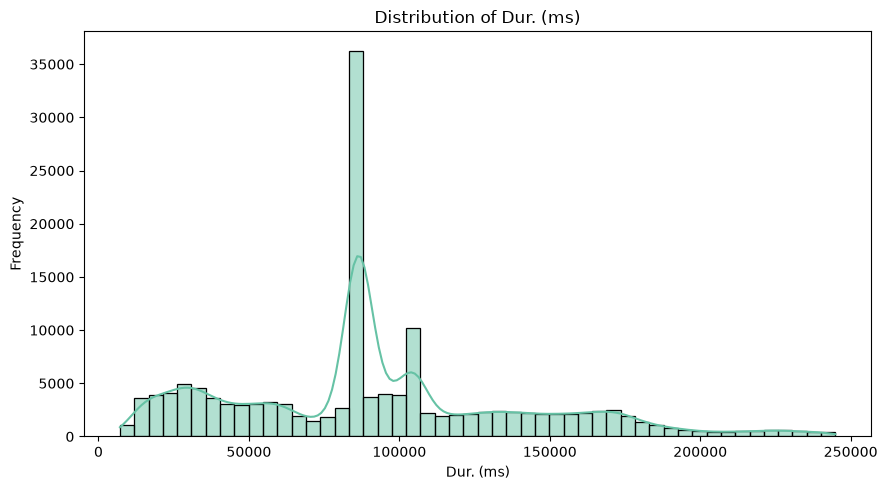

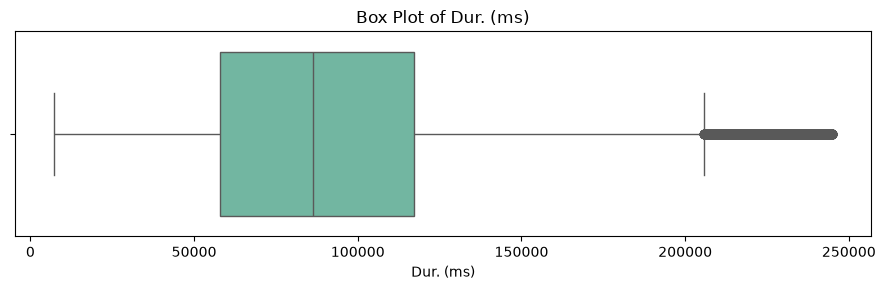

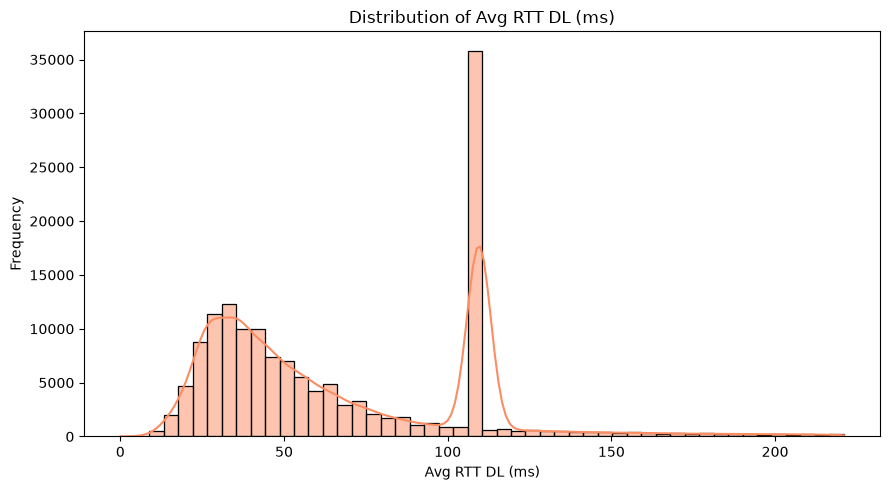

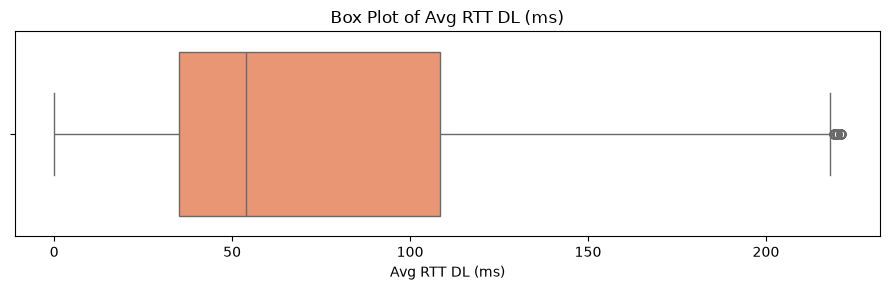

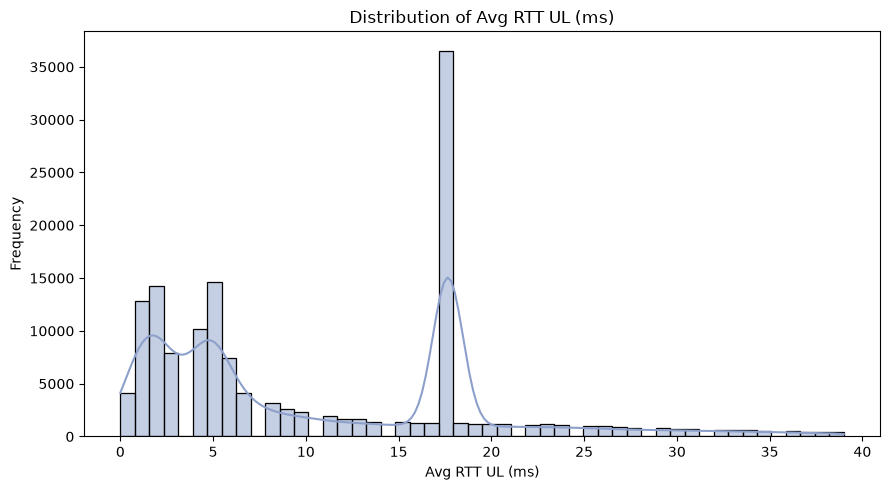

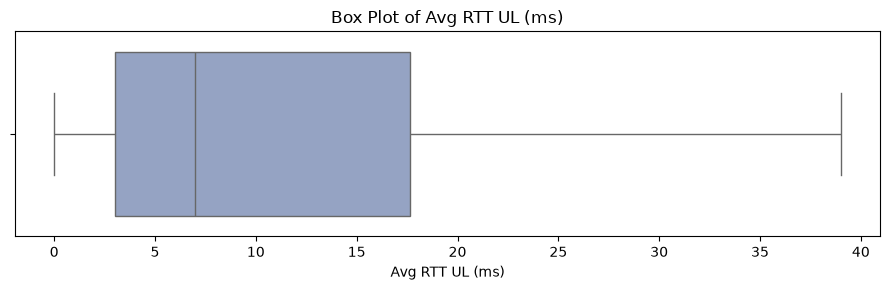

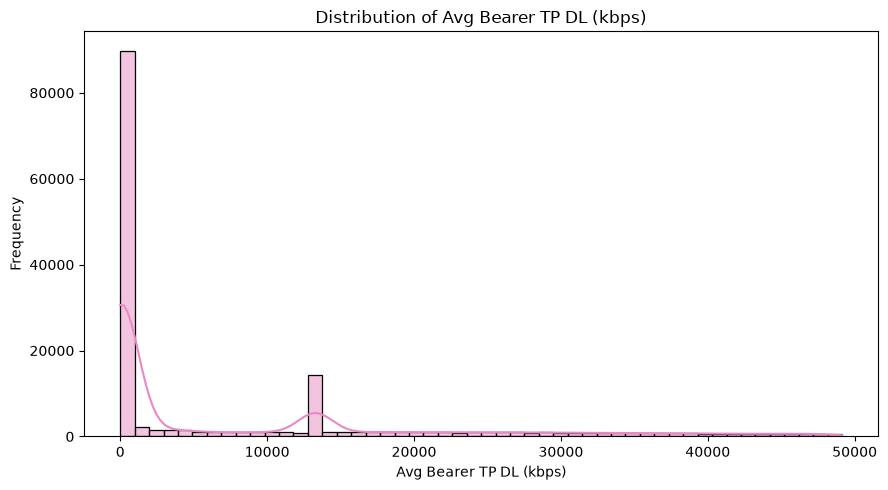

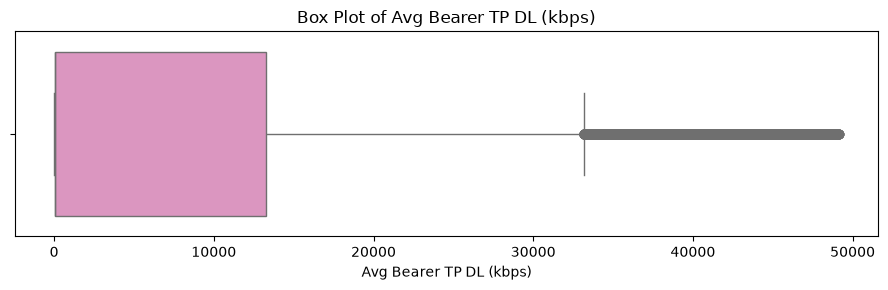

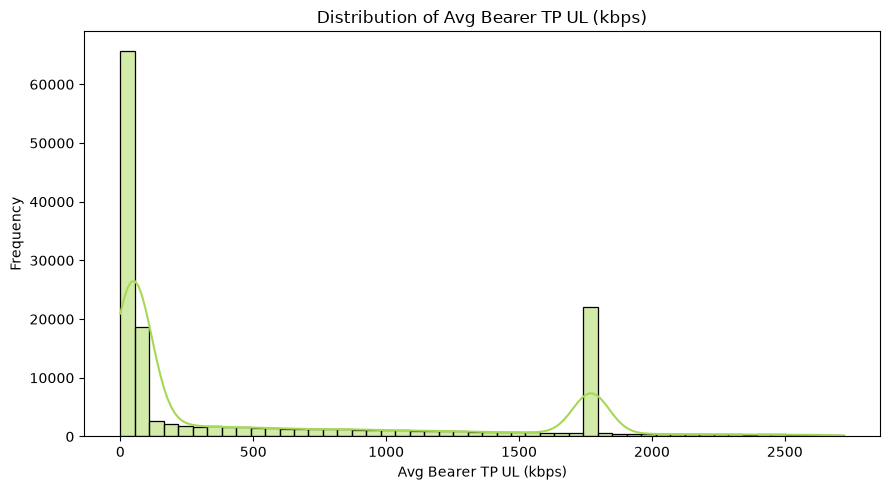

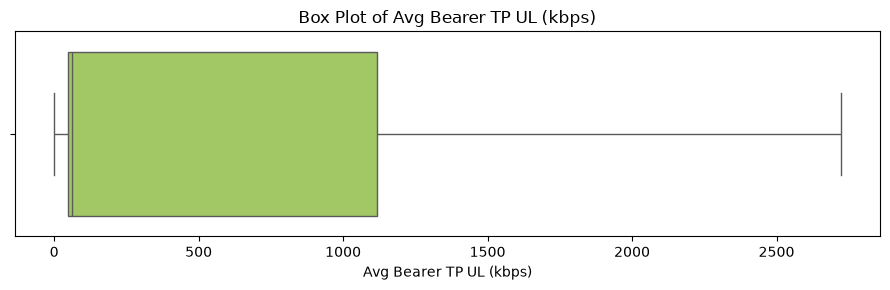

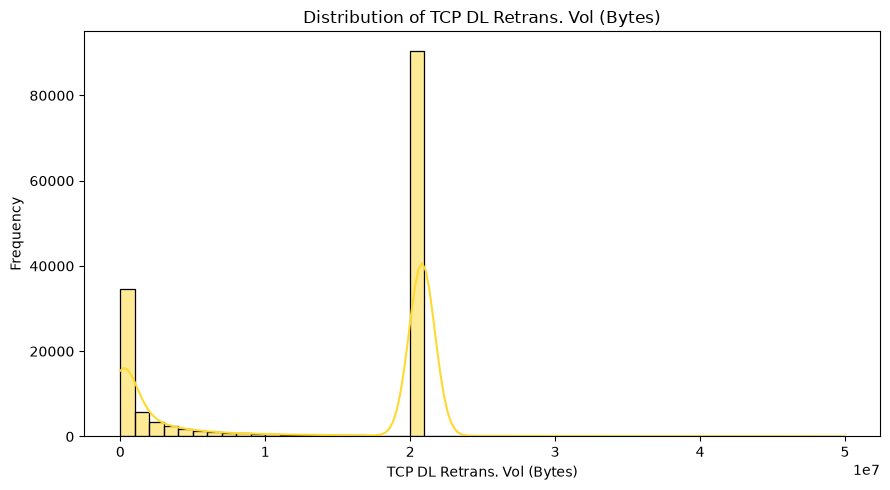

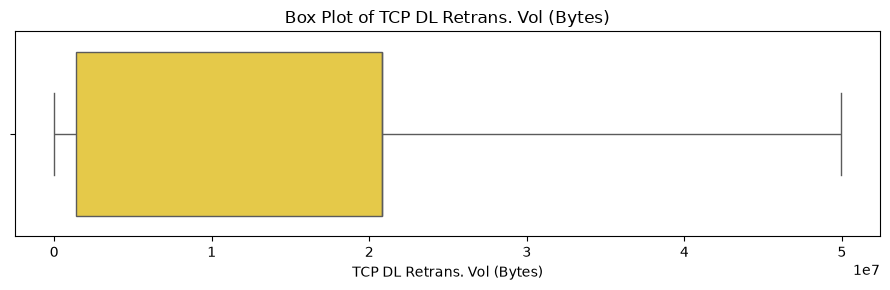

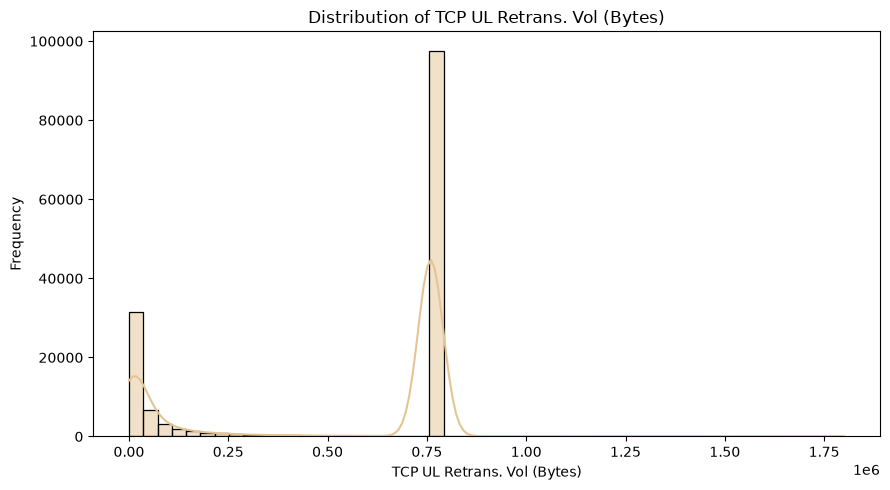

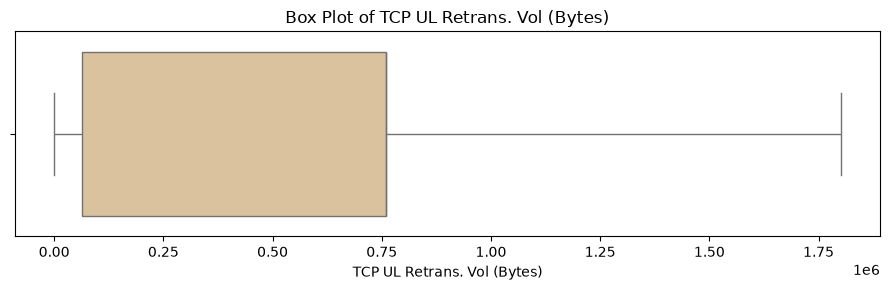

In [ ]:
# Graphical Univariate Analysis
# Visualize the distribution and dispersion of important quantitative variables

selected_univariate_columns = [
    'Dur. (ms)',
    'Avg RTT DL (ms)',
    'Avg RTT UL (ms)',
    'Avg Bearer TP DL (kbps)',
    'Avg Bearer TP UL (kbps)',
    'TCP DL Retrans. Vol (Bytes)',
    'TCP UL Retrans. Vol (Bytes)'
]

# Different colours for different variables
plot_colors = sns.color_palette(
    "Set2",
    n_colors=len(selected_univariate_columns)
)

for col, plot_color in zip(
    selected_univariate_columns,
    plot_colors
):

    # -----------------------------
    # Histogram + KDE
    # -----------------------------
    plt.figure(figsize=(9, 5))

    sns.histplot(
        data=df,
        x=col,
        bins=50,
        kde=True,
        color=plot_color
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Box Plot
    # -----------------------------
    plt.figure(figsize=(9, 3))

    sns.boxplot(
        x=df[col],
        color=plot_color
    )

    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Key Insights from Graphical Univariate Analysis

The graphical univariate analysis of important telecom network performance variables reveals substantial variation in session duration, latency, throughput, and retransmission behaviour.

- **Session Duration (Dur. (ms)):** The distribution is uneven and shows multiple concentrations, with observations distributed across lower and middle duration ranges and a pronounced concentration around the mean-replacement region. The distribution also extends toward higher session durations, indicating considerable variation in session length.

- **Average RTT DL (ms):** Most observations are concentrated at relatively lower downlink RTT values, followed by a right-side tail toward higher latency. A pronounced peak around approximately 108 ms is visible and is partly associated with the mean-based replacement of originally detected outliers.

- **Average RTT UL (ms):** The distribution is concentrated toward lower uplink RTT values and gradually decreases toward higher values. A distinct peak around approximately 17–18 ms is visible due partly to the prescribed mean-based outlier treatment.

- **Average Bearer Throughput DL (kbps):** Most observations are concentrated in the lower downlink-throughput range, while the distribution extends substantially toward higher throughput values. A secondary concentration around approximately 13,286 kbps is visible and is partly influenced by mean-based outlier replacement.

- **Average Bearer Throughput UL (kbps):** The distribution is strongly concentrated toward lower uplink-throughput values, with a distinct secondary peak around approximately 1,770 kbps. The extended right tail indicates that a smaller proportion of observations have considerably higher uplink throughput.

- **TCP DL Retransmission Volume (Bytes):** The distribution is highly concentrated toward lower retransmission volumes and extends toward substantially larger values. A pronounced concentration around approximately 20.84 million bytes is partly associated with the mean-based replacement of originally detected outliers.

- **TCP UL Retransmission Volume (Bytes):** Most observations are concentrated at relatively lower uplink retransmission volumes, followed by a right-side tail toward higher values. A strong concentration around approximately 0.76 million bytes is partly associated with the prescribed mean-based outlier treatment.

### Overall Interpretation

Overall, the selected telecom performance variables exhibit substantial variability and generally show concentration toward lower values with extended right-side tails. Several variables also display pronounced secondary peaks around their corresponding mean values. These peaks should not be interpreted entirely as natural user behaviour because the prescribed outlier-treatment method replaced detected outliers with the corresponding column mean, which can create artificial concentrations in the post-treatment distributions.

The graphical analysis therefore provides two important findings: first, telecom network performance varies considerably across sessions; and second, the observed distributions should be interpreted in the context of the applied data-cleaning methodology. These findings support the subsequent user-level aggregation, bivariate analysis, correlation analysis, dimensionality reduction, and segmentation stages of the project.

### 1.1.12 **Bivariate Analysis**

Bivariate analysis is performed to explore the relationship between individual application data usage and the overall total data traffic (Total DL + UL).

The analysis focuses on the following applications:
- Social Media
- Google
- Email
- YouTube
- Netflix
- Gaming
- Other

For each application, the relationship with total data traffic will be examined using appropriate visual and statistical methods.

In [ ]:
# Define application-wise Download (DL) and Upload (UL) columns

application_columns = {
    'Social Media': ['Social Media DL (Bytes)', 'Social Media UL (Bytes)'],
    'Google': ['Google DL (Bytes)', 'Google UL (Bytes)'],
    'Email': ['Email DL (Bytes)', 'Email UL (Bytes)'],
    'YouTube': ['Youtube DL (Bytes)', 'Youtube UL (Bytes)'],
    'Netflix': ['Netflix DL (Bytes)', 'Netflix UL (Bytes)'],
    'Gaming': ['Gaming DL (Bytes)', 'Gaming UL (Bytes)'],
    'Other': ['Other DL (Bytes)', 'Other UL (Bytes)']
}

print("Application DL and UL columns defined successfully.")

Application DL and UL columns defined successfully.


In [ ]:
# Calculate application-wise total data (DL + UL)
# and overall total traffic for bivariate analysis

application_total_data = {}

for application, columns in application_columns.items():
    dl_column = columns[0]
    ul_column = columns[1]
    
    application_total_data[application] = (
        df[dl_column] + df[ul_column]
    )

# Calculate total network traffic (Total DL + Total UL)
total_traffic = (
    df['Total DL (Bytes)'] +
    df['Total UL (Bytes)']
)

print("Application-wise total data and overall total traffic calculated successfully.")

Application-wise total data and overall total traffic calculated successfully.


In [ ]:
# Create a summary of total data usage by application

application_usage_summary = pd.DataFrame({
    'Application': list(application_total_data.keys()),
    'Total Data (Bytes)': [
        values.sum() for values in application_total_data.values()
    ]
})

# Sort applications by total data usage
application_usage_summary = application_usage_summary.sort_values(
    by='Total Data (Bytes)',
    ascending=False
).reset_index(drop=True)

application_usage_summary

,Application,Total Data (Bytes)
0,Gaming,6.408892e+13
1,Other,6.395425e+13
2,YouTube,3.372204e+12
3,Netflix,3.370060e+12
4,Google,1.162853e+12
5,Email,3.364677e+11
6,Social Media,2.722655e+11


In [ ]:
# Calculate the correlation between each application
# and the overall total network traffic

bivariate_correlation = pd.DataFrame({
    'Application': list(application_total_data.keys()),
    'Correlation with Total Traffic': [
        application_total_data[application].corr(total_traffic)
        for application in application_total_data
    ]
})

# Sort by correlation strength
bivariate_correlation = bivariate_correlation.sort_values(
    by='Correlation with Total Traffic',
    ascending=False
).reset_index(drop=True)

bivariate_correlation

,Application,Correlation with Total Traffic
0,Gaming,0.998263
1,Netflix,0.034583
2,YouTube,0.034577
3,Google,0.013359
4,Social Media,0.005707
5,Email,0.003912
6,Other,-0.002562


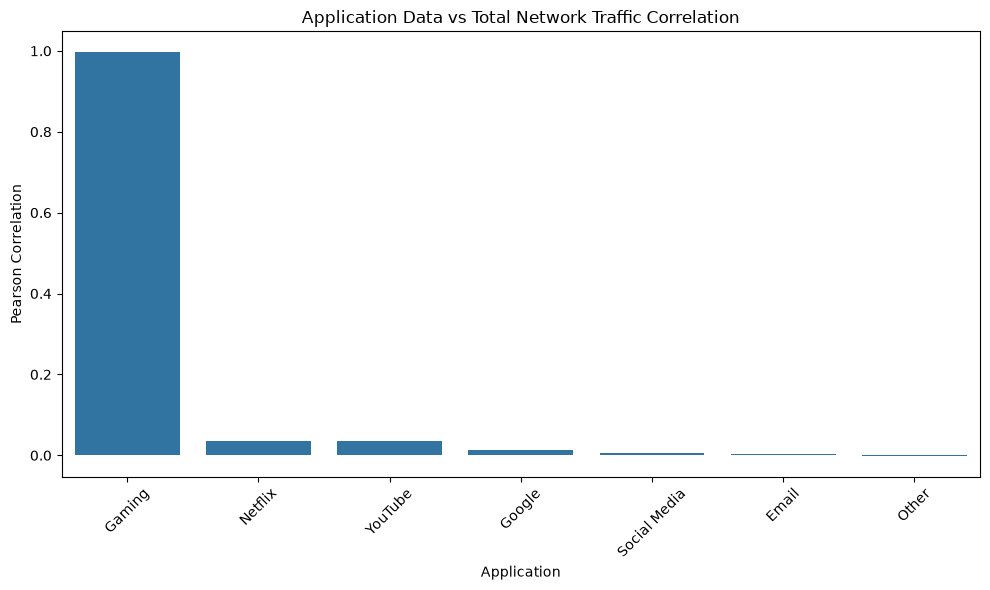

In [ ]:
# Visualize the relationship between each application
# and total network traffic

plt.figure(figsize=(10, 6))

sns.barplot(
    data=bivariate_correlation,
    x='Application',
    y='Correlation with Total Traffic'
)

plt.title('Application Data vs Total Network Traffic Correlation')
plt.xlabel('Application')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Key Insights from Bivariate Analysis**

- **Gaming** shows a very strong positive correlation with total network traffic, with a correlation coefficient of approximately **0.998**. This indicates that gaming data usage moves closely with overall network traffic in this dataset.

- **Netflix and YouTube** show very weak positive correlations with total network traffic, with correlation values of approximately **0.035**. Their individual traffic variation has a limited linear relationship with the overall traffic measure.

- **Google, Social Media, and Email** show correlations very close to zero, indicating very weak linear relationships with total network traffic.

- **Other** application traffic shows an almost zero and slightly negative correlation with total network traffic.

- The very high correlation observed for Gaming should be interpreted cautiously because application traffic is included within the overall **Total DL + UL traffic** measure. Therefore, correlation here indicates association with total traffic and does not establish a causal relationship.

### 1.1.13 **User-Level Aggregation for Decile Analysis**

The telecom dataset contains multiple xDR sessions for each customer. To analyze user-level behaviour, session records are aggregated using the customer identifier (MSISDN/Number).

The following user-level metrics are prepared:
- Number of xDR sessions
- Total session duration
- Total download (DL) and upload (UL) traffic
- Total application data usage for Social Media, Google, Email, YouTube, Netflix, Gaming, and Other

This user-level dataset will be reused for the decile analysis and subsequent User Engagement Analysis.

In [ ]:
# Aggregate telecom session data at customer level

application_total_columns = {
    'Social Media': [
        'Social Media DL (Bytes)',
        'Social Media UL (Bytes)'
    ],
    'Google': [
        'Google DL (Bytes)',
        'Google UL (Bytes)'
    ],
    'Email': [
        'Email DL (Bytes)',
        'Email UL (Bytes)'
    ],
    'YouTube': [
        'Youtube DL (Bytes)',
        'Youtube UL (Bytes)'
    ],
    'Netflix': [
        'Netflix DL (Bytes)',
        'Netflix UL (Bytes)'
    ],
    'Gaming': [
        'Gaming DL (Bytes)',
        'Gaming UL (Bytes)'
    ],
    'Other': [
        'Other DL (Bytes)',
        'Other UL (Bytes)'
    ]
}

# Create user-level aggregation
user_level_data = (
    df.groupby('MSISDN/Number')
      .agg(
          xDR_Sessions=('MSISDN/Number', 'size'),
          Total_Session_Duration_ms=('Dur. (ms)', 'sum'),
          Total_DL_Bytes=('Total DL (Bytes)', 'sum'),
          Total_UL_Bytes=('Total UL (Bytes)', 'sum')
      )
      .reset_index()
)

# Calculate total traffic
user_level_data['Total_Traffic_Bytes'] = (
    user_level_data['Total_DL_Bytes'] +
    user_level_data['Total_UL_Bytes']
)

# Add total application traffic for each user
for application, columns in application_total_columns.items():
    dl_column, ul_column = columns

    user_level_data[f'{application}_Data_Bytes'] = (
        df.assign(
            Application_Total=df[dl_column] + df[ul_column]
        )
        .groupby('MSISDN/Number')['Application_Total']
        .sum()
        .reindex(user_level_data['MSISDN/Number'])
        .to_numpy()
    )

print("User-level aggregation completed successfully.")
print("Number of users:", len(user_level_data))
print("User-level dataset shape:", user_level_data.shape)

User-level aggregation completed successfully.
Number of users: 106856
User-level dataset shape: (106856, 13)


### 1.1.14 **Decile Analysis Based on Total Session Duration**

Users are segmented into decile classes based on their total session duration.

The objective is to understand how total network traffic (DL + UL) varies across users with different levels of session activity.

In [ ]:
# Create decile classes based on total session duration

user_level_data['Duration_Decile'] = pd.qcut(
    user_level_data['Total_Session_Duration_ms'],
    q=10,
    labels=False,
    duplicates='drop'
) + 1

# Calculate total traffic for each decile
decile_analysis = (
    user_level_data
    .groupby('Duration_Decile')
    .agg(
        Users=('MSISDN/Number', 'count'),
        Total_Session_Duration_ms=('Total_Session_Duration_ms', 'sum'),
        Total_Traffic_Bytes=('Total_Traffic_Bytes', 'sum')
    )
    .reset_index()
)

decile_analysis

,Duration_Decile,Users,Total_Session_Duration_ms,Total_Traffic_Bytes
0,1,10688,2.145383e+08,5.439240e+12
1,2,10684,4.298068e+08,6.109452e+12
2,3,10744,7.643883e+08,6.536499e+12
3,4,12082,1.043508e+09,6.034377e+12
4,5,9230,8.701137e+08,5.143763e+12
5,6,10686,1.183709e+09,6.186639e+12
6,7,10685,1.485583e+09,6.108393e+12
7,8,10687,1.793819e+09,7.408509e+12
8,9,10684,2.209390e+09,8.649643e+12
9,10,10686,3.870278e+09,1.621664e+13


### 1.1.14.1 **Top Five Decile Classes Based on Session Duration**

After aggregating the session-level records at the user level, users were divided into **10 decile classes** based on their total session duration.

- **Deciles 1–10** represent users from lower to higher levels of total session duration.
- **Deciles 1–5** represent users with relatively lower session activity.
- **Deciles 6–10** represent users with relatively higher session activity.

The project guideline specifically requires analysis of the **top five decile classes** based on total session duration. Therefore, the analysis now focuses on **Deciles 6–10** to examine the total download and upload traffic generated by users with higher session activity.

This helps identify whether users with higher session duration also contribute substantially to overall network traffic.

In [ ]:
# Analyze the top five decile classes

top_five_deciles = decile_analysis[
    decile_analysis['Duration_Decile'].isin([6, 7, 8, 9, 10])
].copy()

top_five_deciles

,Duration_Decile,Users,Total_Session_Duration_ms,Total_Traffic_Bytes
5,6,10686,1.183709e+09,6.186639e+12
6,7,10685,1.485583e+09,6.108393e+12
7,8,10687,1.793819e+09,7.408509e+12
8,9,10684,2.209390e+09,8.649643e+12
9,10,10686,3.870278e+09,1.621664e+13


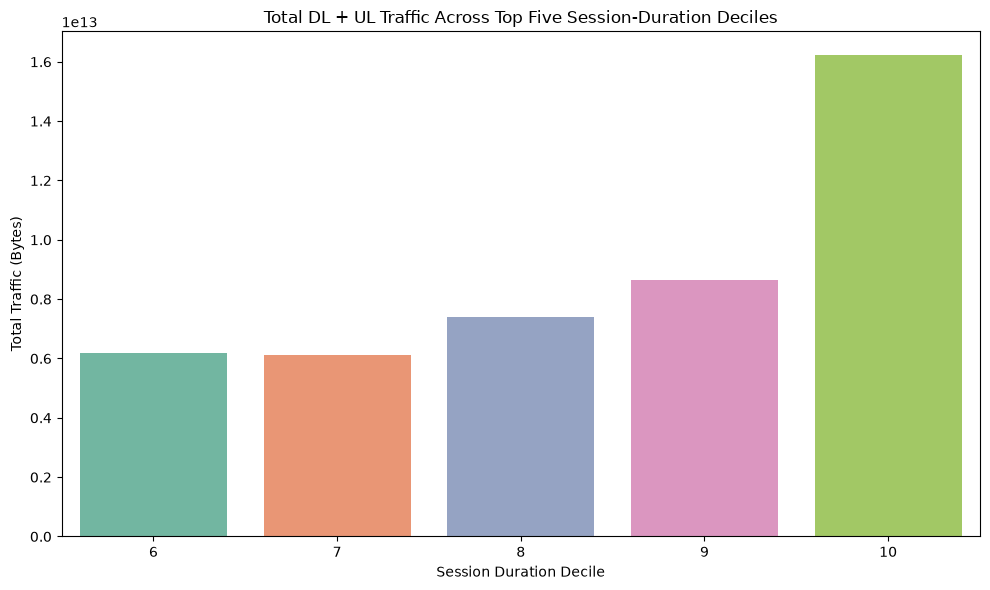

In [ ]:
# Visualize total traffic across the top five session-duration deciles

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_five_deciles,
    x='Duration_Decile',
    y='Total_Traffic_Bytes',
    hue='Duration_Decile',
    palette='Set2',
    legend=False
)

plt.title('Total DL + UL Traffic Across Top Five Session-Duration Deciles')
plt.xlabel('Session Duration Decile')
plt.ylabel('Total Traffic (Bytes)')
plt.tight_layout()
plt.show()

### Decile-wise Interpretation

- Total DL + UL traffic generally increases across the higher session-duration deciles, although a small fluctuation is observed between Deciles 6 and 7.
- Decile 10 has the highest total session duration and the highest total traffic.
- Higher-duration users generally contribute more overall network traffic.
- The highest-duration user segment therefore represents an important group for understanding heavy network usage.

### 1.1.15 **Application-Level Correlation Analysis**

The earlier bivariate analysis examined the relationship between individual application traffic and overall network traffic.

To extend this analysis without duplicating the earlier comparison, the correlation between the seven application-level data volumes is now examined at the user level.

The analysis includes:
- Social Media
- Google
- Email
- YouTube
- Netflix
- Gaming
- Other

A Pearson correlation matrix is used to identify the strength and direction of linear relationships between application data usage patterns.

In [ ]:
# Select user-level application data for correlation analysis

application_data_columns = [
    'Social Media_Data_Bytes',
    'Google_Data_Bytes',
    'Email_Data_Bytes',
    'YouTube_Data_Bytes',
    'Netflix_Data_Bytes',
    'Gaming_Data_Bytes',
    'Other_Data_Bytes'
]

# Calculate Pearson correlation matrix
application_correlation_matrix = (
    user_level_data[application_data_columns]
    .corr(method='pearson')
)

# Rename columns and index for readability
application_correlation_matrix.columns = [
    'Social Media',
    'Google',
    'Email',
    'YouTube',
    'Netflix',
    'Gaming',
    'Other'
]

application_correlation_matrix.index = (
    application_correlation_matrix.columns
)

application_correlation_matrix

,Social Media,Google,Email,YouTube,Netflix,Gaming,Other
Social Media,1.000000,0.643071,0.634016,0.659545,0.659974,0.590048,0.591727
Google,0.643071,1.000000,0.688460,0.718539,0.716191,0.642037,0.642608
Email,0.634016,0.688460,1.000000,0.704632,0.705466,0.627474,0.631024
YouTube,0.659545,0.718539,0.704632,1.000000,0.738445,0.657408,0.660380
Netflix,0.659974,0.716191,0.705466,0.738445,1.000000,0.657408,0.655831
Gaming,0.590048,0.642037,0.627474,0.657408,0.657408,1.000000,0.586394
Other,0.591727,0.642608,0.631024,0.660380,0.655831,0.586394,1.000000


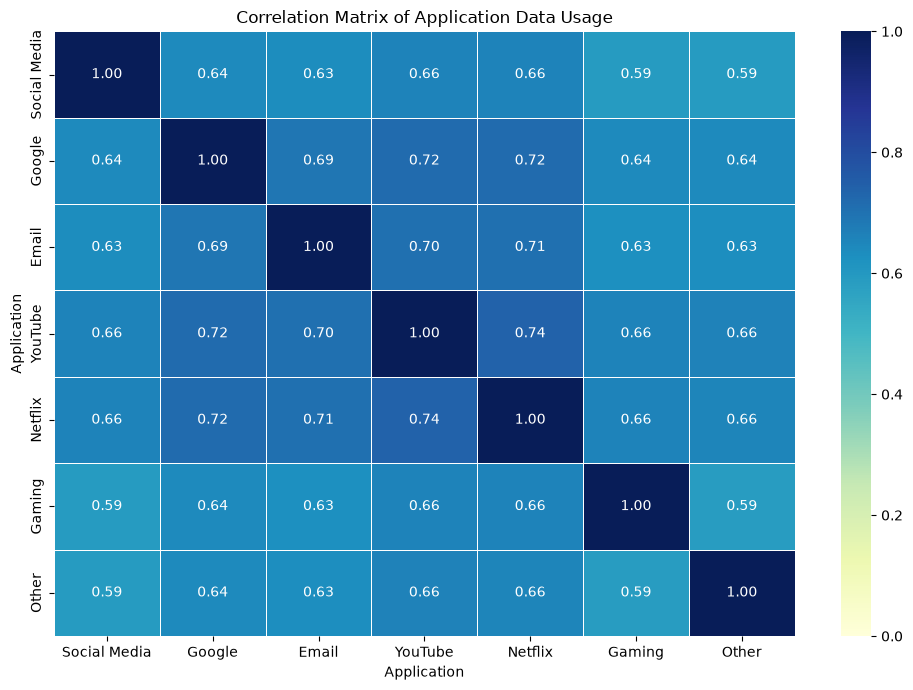

In [ ]:
# Visualize application-level correlations using a heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    application_correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title('Correlation Matrix of Application Data Usage')
plt.xlabel('Application')
plt.ylabel('Application')
plt.tight_layout()
plt.show()

### 1.1.15.1 **Key Insights from Application-Level Correlation Analysis**

- All seven application categories show positive correlations with one another, with correlation coefficients ranging from approximately 0.59 to 0.74.
- The strongest relationship is observed between **YouTube and Netflix (r = 0.74)**, indicating that users with higher usage of one of these applications tend to also show higher usage of the other.
- **Google and YouTube (r = 0.72)** and **Google and Netflix (r = 0.72)** also show relatively strong positive relationships.
- **Social Media and Google (r = 0.64)** and **Social Media and Netflix (r = 0.66)** indicate moderate positive relationships.
- The comparatively lower correlation is observed between **Gaming and Other (r = 0.59)**, although the relationship remains positive.
- Overall, the results indicate that application data usage patterns tend to move together at the user level. These correlations represent associations between application usage and do not establish causation.

### 1.1.16 **Principal Component Analysis (PCA)**

Principal Component Analysis (PCA) is applied to reduce the dimensionality of the seven application-level data usage variables while retaining as much information as possible.

The PCA is performed on standardized user-level application data because the application variables may differ in their scale and magnitude.

The seven application variables used are:
- Social Media
- Google
- Email
- YouTube
- Netflix
- Gaming
- Other

The objective is to identify a smaller set of principal components that can represent the major patterns in application usage.

In [ ]:
# Standardize the seven application-level variables before PCA

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select application-level user data
pca_data = user_level_data[application_data_columns].copy()

# Standardize the variables
scaler = StandardScaler()

pca_scaled_data = scaler.fit_transform(pca_data)

print("Application data standardized successfully.")
print("Original dimensions:", pca_data.shape[1])
print("Number of users:", pca_data.shape[0])

Application data standardized successfully.
Original dimensions: 7
Number of users: 106856


In [ ]:
# Perform PCA to examine explained variance

pca_full = PCA()

pca_full_data = pca_full.fit_transform(pca_scaled_data)

explained_variance = pca_full.explained_variance_ratio_

pca_variance_summary = pd.DataFrame({
    'Principal Component': [
        f'PC{i+1}' for i in range(len(explained_variance))
    ],
    'Explained Variance (%)': explained_variance * 100,
    'Cumulative Variance (%)': (
        explained_variance.cumsum() * 100
    )
})

pca_variance_summary

,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,70.735526,70.735526
1,PC2,5.912166,76.647692
2,PC3,5.822164,82.469856
3,PC4,5.241703,87.711560
4,PC5,4.467555,92.179115
5,PC6,4.086381,96.265496
6,PC7,3.734504,100.000000


In [ ]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

pca_variance_df = pd.DataFrame({
    'Principal_Component': range(1, len(cumulative_variance) + 1),
    'Explained_Variance_Ratio': pca_full.explained_variance_ratio_,
    'Cumulative_Variance': cumulative_variance
})

display(pca_variance_df.head(10))

,Principal_Component,Explained_Variance_Ratio,Cumulative_Variance
0,1,0.707355,0.707355
1,2,0.059122,0.766477
2,3,0.058222,0.824699
3,4,0.052417,0.877116
4,5,0.044676,0.921791
5,6,0.040864,0.962655
6,7,0.037345,1.000000


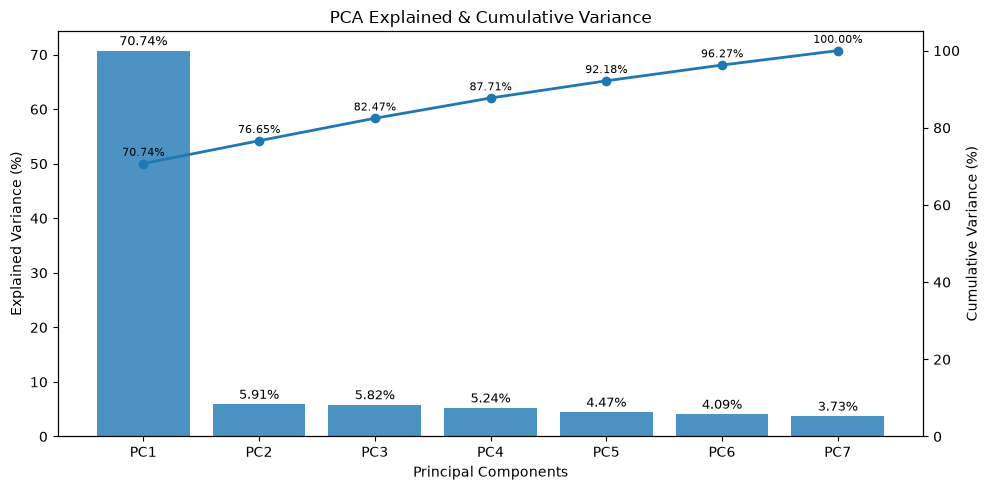

In [ ]:
# PCA Explained Variance Visual

import matplotlib.pyplot as plt

pc_labels = [f"PC{i}" for i in pca_variance_df["Principal_Component"]]

explained_pct = pca_variance_df["Explained_Variance_Ratio"] * 100
cumulative_pct = pca_variance_df["Cumulative_Variance"] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

# Explained variance bars
ax1.bar(
    pc_labels,
    explained_pct,
    alpha=0.8,
    label="Explained Variance (%)"
)

ax1.set_xlabel("Principal Components")
ax1.set_ylabel("Explained Variance (%)")
ax1.set_title("PCA Explained & Cumulative Variance")

# Cumulative variance line
ax2 = ax1.twinx()

ax2.plot(
    pc_labels,
    cumulative_pct,
    marker="o",
    linewidth=2,
    label="Cumulative Variance (%)"
)

ax2.set_ylabel("Cumulative Variance (%)")
ax2.set_ylim(0, 105)

# Add percentage labels
for i, value in enumerate(explained_pct):
    ax1.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

for i, value in enumerate(cumulative_pct):
    ax2.text(
        i,
        value + 2,
        f"{value:.2f}%",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [ ]:
pca_loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_full.n_components_)],
    index=application_data_columns
)

pca_loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Social Media_Data_Bytes,0.363949,-0.121892,0.795356,-0.460023,0.061019,0.068849,0.002787
Google_Data_Bytes,0.386455,0.001332,-0.006166,0.310210,-0.594541,0.631949,-0.039292
Email_Data_Bytes,0.381613,-0.027172,0.027314,0.490135,0.747862,0.230688,0.011835
YouTube_Data_Bytes,0.393508,-0.009392,-0.007250,0.206896,-0.198684,-0.483976,0.726977
Netflix_Data_Bytes,0.393064,0.008663,0.011765,0.220957,-0.165819,-0.547339,-0.685120
Gaming_Data_Bytes,0.362477,0.773120,-0.297702,-0.409050,0.100673,0.069364,0.000920
Other_Data_Bytes,0.363080,-0.621711,-0.527074,-0.439280,0.079959,0.063716,-0.020533


In [ ]:
# Create a PCA-reduced dataset using the first three principal components

pca_reduced_data = pd.DataFrame(
    pca_full_data[:, :3],
    columns=['PC1', 'PC2', 'PC3']
)

print("PCA-reduced dataset created successfully.")
print("Original dimensions:", pca_data.shape[1])
print("Reduced dimensions:", pca_reduced_data.shape[1])
print("PCA-reduced dataset shape:", pca_reduced_data.shape)

pca_reduced_data.head()

PCA-reduced dataset created successfully.
Original dimensions: 7
Reduced dimensions: 3
PCA-reduced dataset shape: (106856, 3)


,PC1,PC2,PC3
0,-0.968704,0.703475,-0.039848
1,-1.607525,-0.397470,0.738824
2,-0.789185,-0.014647,0.427560
3,-2.267178,0.574899,-0.163320
4,1.740944,0.924008,-0.562105


### PCA Interpretation

- **PC1 explains 70.74% of the total variance**, with positive and relatively similar loadings across all seven application data variables. This indicates that PC1 mainly represents an overall application data usage dimension.

- **PC2 explains 5.91% of the variance** and is strongly associated with Gaming data (loading = 0.7731) while showing a negative loading for Other data (loading = -0.6217). This component represents a contrast between Gaming and Other application usage.

- **PC3 explains 5.82% of the variance** and has a strong positive loading for Social Media data (0.7954), while Other data has a negative loading (-0.5271). This suggests a contrast between Social Media and Other application usage.

- **The first three principal components together explain 82.47% of the total variance**, showing that most of the information in the seven application variables can be represented using three dimensions instead of seven.

## 1.2 **Handset and Manufacturer Analysis**

In [ ]:
# Identify the top 10 most frequently observed handsets

top_10_handsets = (
    df.loc[
        df['Handset Type'].notna()
        & (df['Handset Type'].str.strip().str.lower() != 'undefined'),
        'Handset Type'
    ]
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_handsets.columns = ['Handset Type', 'Usage Count']

top_10_handsets

,Handset Type,Usage Count
0,Huawei B528S-23A,19727
1,Apple iPhone 6S (A1688),9413
2,Apple iPhone 6 (A1586),9012
3,Apple iPhone 7 (A1778),6304
4,Apple iPhone Se (A1723),5176
5,Apple iPhone 8 (A1905),4985
6,Apple iPhone Xr (A2105),4562
7,Samsung Galaxy S8 (Sm-G950F),4480
8,Apple iPhone X (A1901),3810
9,Samsung Galaxy A5 Sm-A520F,3708


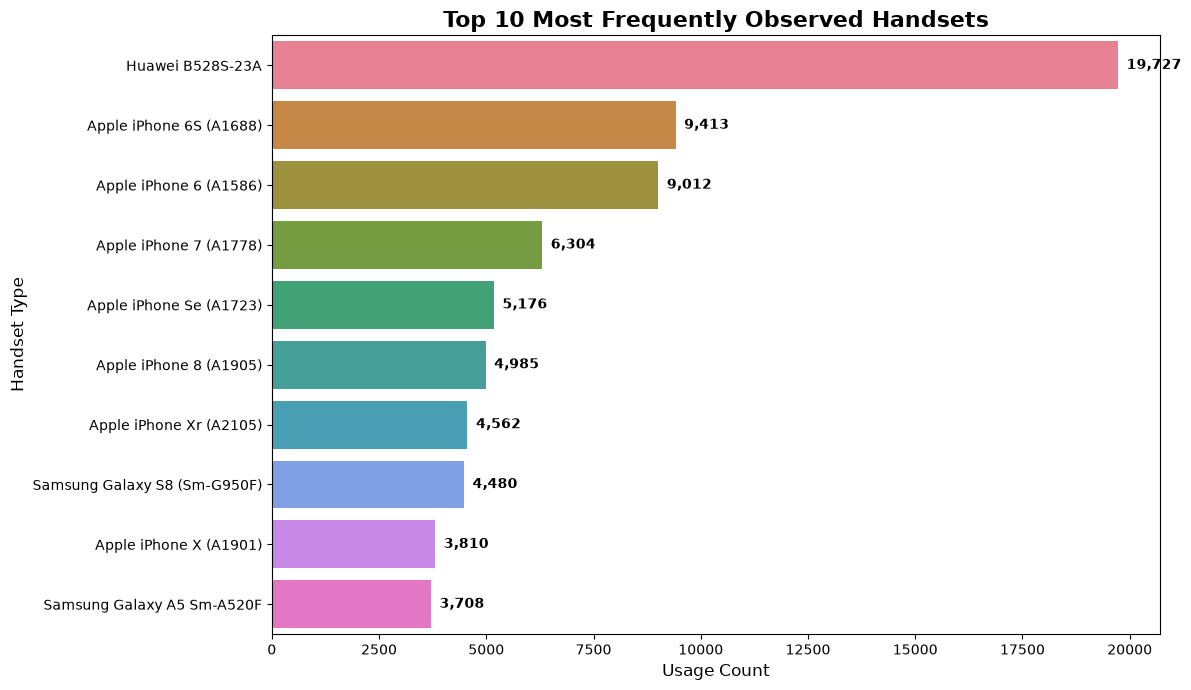

In [ ]:
# Visualize the top 10 most frequently observed handsets

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_handsets,
    x='Usage Count',
    y='Handset Type',
    hue='Handset Type',
    palette='husl',
    legend=False
)

plt.title(
    'Top 10 Most Frequently Observed Handsets',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Usage Count', fontsize=12)
plt.ylabel('Handset Type', fontsize=12)

# Add value labels at the end of each bar
for i, value in enumerate(top_10_handsets['Usage Count']):
    plt.text(
        value + 200,
        i,
        f'{value:,}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
# Identify the top 3 most frequently observed handset manufacturers

top_3_manufacturers = (
    df.loc[
        df['Handset Manufacturer'].notna()
        & (
            df['Handset Manufacturer']
            .str.strip()
            .str.lower() != 'undefined'
        ),
        'Handset Manufacturer'
    ]
    .value_counts()
    .head(3)
    .reset_index()
)

top_3_manufacturers.columns = [
    'Handset Manufacturer',
    'Usage Count'
]

top_3_manufacturers

,Handset Manufacturer,Usage Count
0,Apple,59464
1,Samsung,40579
2,Huawei,34366


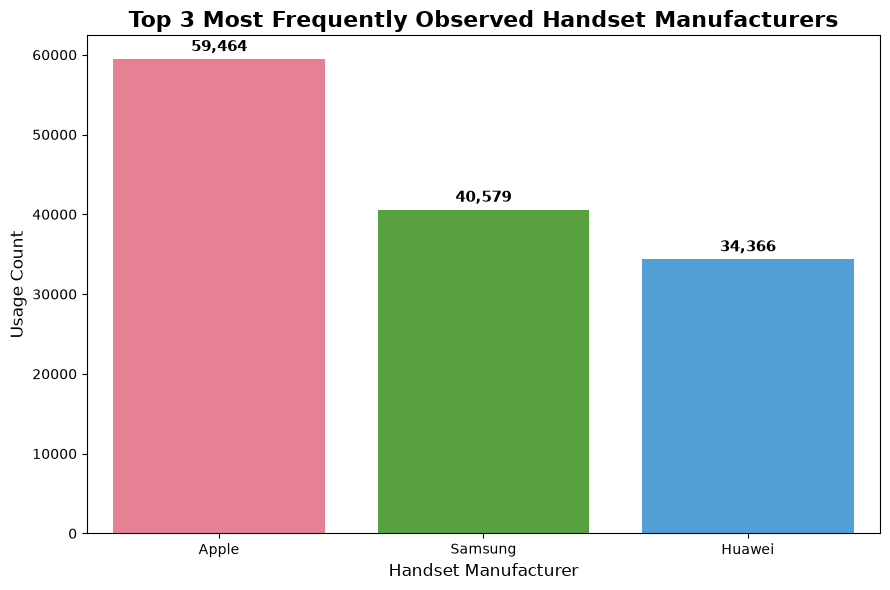

In [ ]:
# Visualize the top 3 most frequently observed handset manufacturers

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_3_manufacturers,
    x='Handset Manufacturer',
    y='Usage Count',
    hue='Handset Manufacturer',
    palette='husl',
    legend=False
)

plt.title(
    'Top 3 Most Frequently Observed Handset Manufacturers',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Handset Manufacturer', fontsize=12)
plt.ylabel('Usage Count', fontsize=12)

# Add value labels on top of each bar
for i, value in enumerate(top_3_manufacturers['Usage Count']):
    plt.text(
        i,
        value + 1000,
        f'{value:,}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
# Identify the top 5 handsets for each of the top 3 manufacturers

top_3_manufacturer_names = (
    top_3_manufacturers['Handset Manufacturer']
    .tolist()
)

top_5_handsets_by_manufacturer = []

for manufacturer in top_3_manufacturer_names:

    manufacturer_handsets = (
        df.loc[
            (df['Handset Manufacturer'] == manufacturer)
            & df['Handset Type'].notna()
            & (
                df['Handset Type']
                .str.strip()
                .str.lower() != 'undefined'
            ),
            'Handset Type'
        ]
        .value_counts()
        .head(5)
        .reset_index()
    )

    manufacturer_handsets.columns = [
        'Handset Type',
        'Usage Count'
    ]

    manufacturer_handsets['Handset Manufacturer'] = manufacturer

    top_5_handsets_by_manufacturer.append(
        manufacturer_handsets
    )

top_5_handsets_by_manufacturer = pd.concat(
    top_5_handsets_by_manufacturer,
    ignore_index=True
)

top_5_handsets_by_manufacturer = (
    top_5_handsets_by_manufacturer[
        [
            'Handset Manufacturer',
            'Handset Type',
            'Usage Count'
        ]
    ]
)

top_5_handsets_by_manufacturer

,Handset Manufacturer,Handset Type,Usage Count
0,Apple,Apple iPhone 6S (A1688),9413
1,Apple,Apple iPhone 6 (A1586),9012
2,Apple,Apple iPhone 7 (A1778),6304
3,Apple,Apple iPhone Se (A1723),5176
4,Apple,Apple iPhone 8 (A1905),4985
5,Samsung,Samsung Galaxy S8 (Sm-G950F),4480
6,Samsung,Samsung Galaxy A5 Sm-A520F,3708
7,Samsung,Samsung Galaxy J5 (Sm-J530),3682
8,Samsung,Samsung Galaxy J3 (Sm-J330),3464
9,Samsung,Samsung Galaxy S7 (Sm-G930X),3176


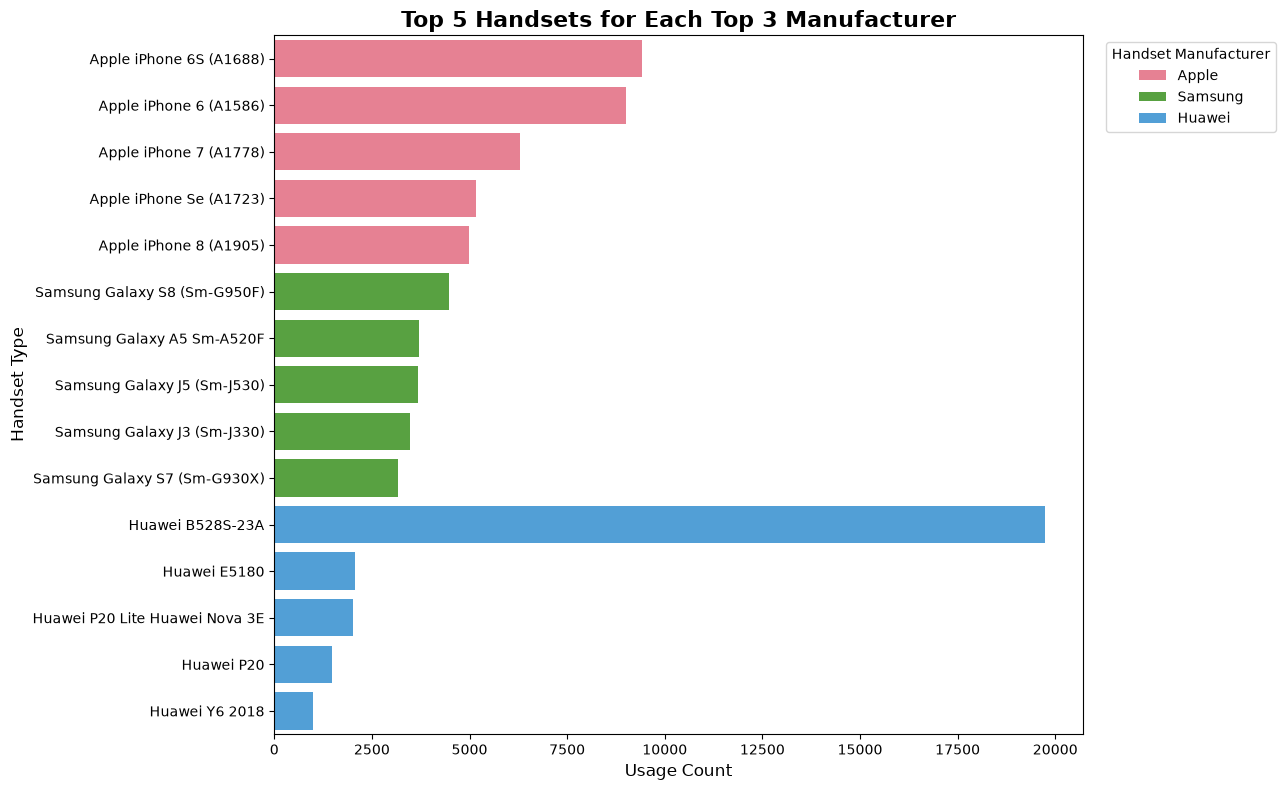

In [ ]:
# Visualize the top 5 handsets for each of the top 3 manufacturers

plt.figure(figsize=(13, 8))

sns.barplot(
    data=top_5_handsets_by_manufacturer,
    x='Usage Count',
    y='Handset Type',
    hue='Handset Manufacturer',
    palette='husl'
)

plt.title(
    'Top 5 Handsets for Each Top 3 Manufacturer',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Usage Count', fontsize=12)
plt.ylabel('Handset Type', fontsize=12)

plt.legend(
    title='Handset Manufacturer',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Marketing Interpretation and Recommendations

- **Apple, Samsung, and Huawei** are the three most frequently observed handset manufacturers in the dataset, indicating strong representation of these brands in the observed telecom records.

- **Huawei B528S-23A** is the most frequently observed handset model, while several Apple iPhone models also appear prominently among the top-used handset records.

- Marketing teams can use these handset usage patterns to prioritize device-specific campaigns, compatible service offerings, and targeted customer communication.

- The concentration of observed usage across a limited number of handset models can also help optimize testing, service compatibility, and promotional planning for commonly used devices.

In [ ]:
# Save user-level data for reuse in User Engagement Analysis

user_level_data.to_csv(
    '../data/processed/user_level_data.csv',
    index=False
)

print("User-level data saved successfully.")
print("Shape:", user_level_data.shape)

User-level data saved successfully.
Shape: (106856, 14)
